In [1]:
import pandas as pd
import numpy as np
df = pd.read_csv("./archive (4)/UrbanSound8K.csv")
df.head()

,slice_file_name,fsID,start,end,salience,fold,classID,class
0,100032-3-0-0.wav,100032,0.0,0.317551,1,5,3,dog_bark
1,100263-2-0-117.wav,100263,58.5,62.500000,1,5,2,children_playing
2,100263-2-0-121.wav,100263,60.5,64.500000,1,5,2,children_playing
3,100263-2-0-126.wav,100263,63.0,67.000000,1,5,2,children_playing
4,100263-2-0-137.wav,100263,68.5,72.500000,1,5,2,children_playing


In [2]:
import os
import librosa
import librosa.display

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import MinMaxScaler, LabelEncoder

In [4]:
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Activation, Dropout

In [5]:
# Audio Playback (Optional)
import IPython.display as ipd

# Resampling Library
import resampy  

from tqdm.auto import tqdm

c:\Users\hp\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [6]:
dat1, sampling_rate1 = librosa.load('./archive (4)/fold5/100032-3-0-0.wav')
dat2, sampling_rate2 = librosa.load('./archive (4)/fold5/100263-2-0-117.wav')

Text(0.5, 1.0, 'Linear-frequency power spectrogram')

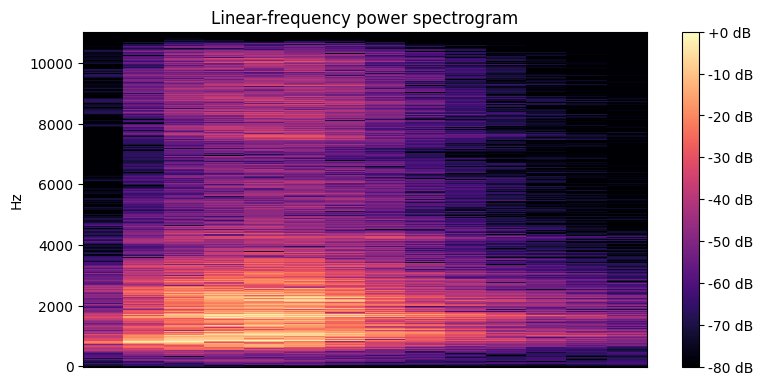

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# Register Matplotlib Converters for Time Series Plots
pd.plotting.register_matplotlib_converters()
%matplotlib inline  
plt.figure(figsize=(20, 20))
D = librosa.amplitude_to_db(np.abs(librosa.stft(dat1)), ref=np.max)
plt.subplot(4, 2, 1)
librosa.display.specshow(D, y_axis='linear')
plt.colorbar(format='%+2.0f dB')
plt.title('Linear-frequency power spectrogram')

Text(0.5, 1.0, 'Linear-frequency power spectrogram')

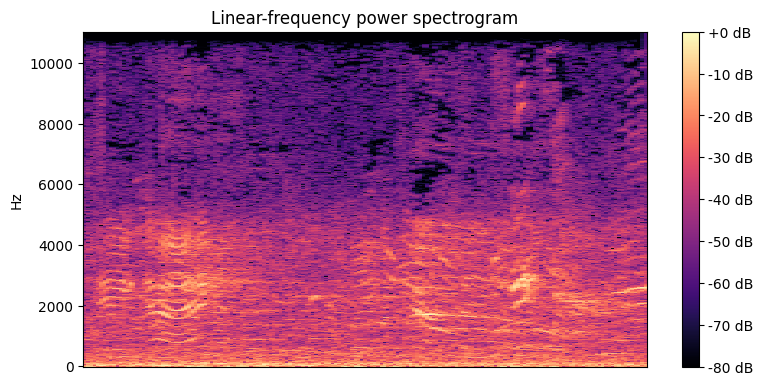

In [8]:
plt.figure(figsize=(20, 20))
D = librosa.amplitude_to_db(np.abs(librosa.stft(dat2)), ref=np.max)
plt.subplot(4, 2, 1)
librosa.display.specshow(D, y_axis='linear')
plt.colorbar(format='%+2.0f dB')
plt.title('Linear-frequency power spectrogram')

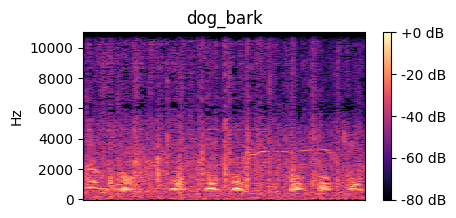

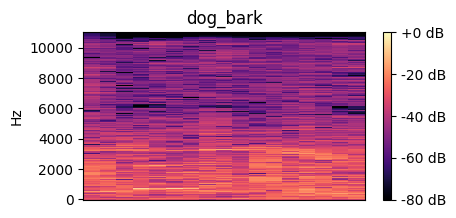

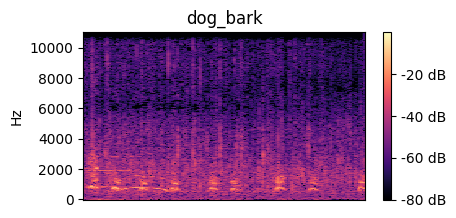

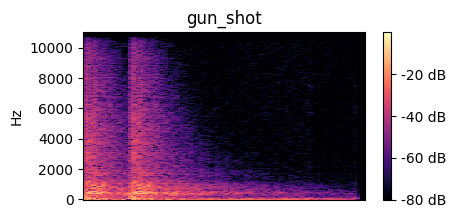

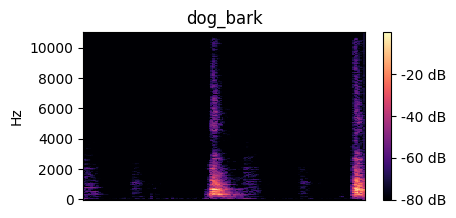

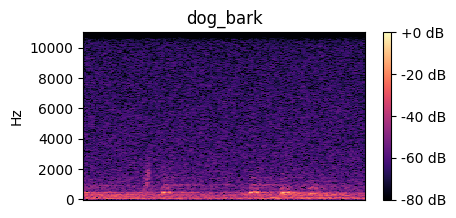

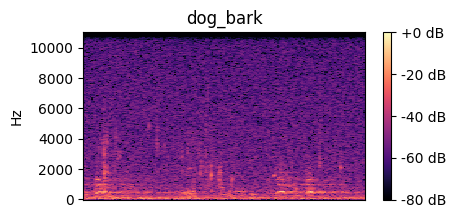

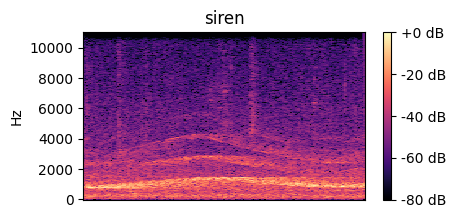

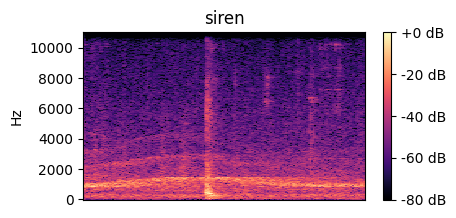

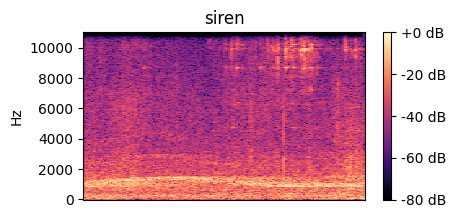

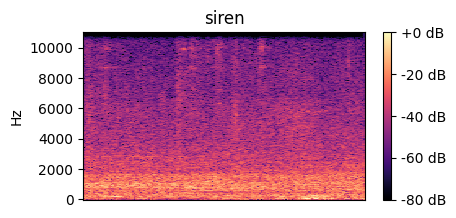

In [9]:
arr = np.array(df["slice_file_name"])
fold = np.array(df["fold"])
cla = np.array(df["class"])

for i in range(100, 121, 2):
    path = './archive (4)/fold' + str(fold[i]) + '/' + arr[i]
    data, sampling_rate = librosa.load(path)
    plt.figure(figsize=(10, 10))
    D = librosa.amplitude_to_db(np.abs(librosa.stft(data)), ref=np.max)
    plt.subplot(4, 2, 1)
    librosa.display.specshow(D, y_axis='linear')
    plt.colorbar(format='%+2.0f dB')
    plt.title(cla[i])

In [10]:
import librosa
import numpy as np

def features_extract(file_name, target_duration=4, sr=22050, n_mfcc=50, n_fft=1024):
    target_length = target_duration * sr  # Total samples for 4 seconds

    sample, sample_rate = librosa.load(file_name, sr=sr)
    if len(sample) < target_length:
        sample = np.pad(sample, (0, target_length - len(sample)), mode='constant')

    feature = librosa.feature.mfcc(y=sample, sr=sample_rate, n_mfcc=n_mfcc, n_fft=n_fft)
    max_pad_len = feature.shape[1]  # Maximum possible frames for 4-sec audio
    pad_width = max(0, max_pad_len - feature.shape[1])
    feature_padded = np.pad(feature, pad_width=((0, 0), (0, pad_width)), mode='constant')
    scaled_feature = np.mean(feature_padded.T, axis=0)
    return scaled_feature


extracted = []
path = './archive (4)'

for index_num, row in tqdm(df.iterrows()):
    file_name = os.path.join(os.path.abspath(path), 'fold' + str(row["fold"]), str(row['slice_file_name'])) 
    final_class_labels = row['class']   
    data = features_extract(file_name)    
    extracted.append([data, final_class_labels])


8732it [02:39, 54.70it/s]


In [11]:
ext_df = pd.DataFrame(extracted,columns=['feature','class'])
ext_df

,feature,class
0,"[-646.75635, 5.3873677, -9.81038, -4.852548, -...",dog_bark
1,"[-490.71515, 98.969734, -42.70029, 51.26325, 9...",children_playing
2,"[-525.64197, 111.47854, -37.607727, 43.46369, ...",children_playing
3,"[-480.8334, 91.745125, -24.20152, 42.91354, 11...",children_playing
4,"[-512.5282, 103.20618, -42.739483, 50.844624, ...",children_playing
...,...,...
8727,"[-463.6058, 124.70258, -40.755966, 25.904419, ...",car_horn
8728,"[-632.8646, 41.30297, -18.6657, 22.987225, -12...",car_horn
8729,"[-429.492, 90.46378, -32.355354, 23.182915, -0...",car_horn
8730,"[-597.676, 73.3897, -28.41001, 15.767284, -6.7...",car_horn


In [12]:
x = np.array(ext_df['feature'].tolist())
y = np.array(ext_df['class'].tolist())
le = LabelEncoder()

y = to_categorical(le.fit_transform(y))
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state = 42)

print("Number of training samples = ", x_train.shape[0])
print("Number of testing samples = ",x_test.shape[0])

Number of training samples =  6985
Number of testing samples =  1747


In [13]:
def extract_feature(file_name, target_duration=4, sr=22050, n_mfcc=50):
    target_length = target_duration * sr 
    audio_data, sample_rate = librosa.load(file_name, sr=sr, res_type='soxr_vhq') 
    if len(audio_data) < target_length:
        audio_data = np.pad(audio_data, (0, target_length - len(audio_data)), mode='constant')
    fea = librosa.feature.mfcc(y=audio_data, sr=sample_rate, n_mfcc=n_mfcc)
    scaled = np.mean(fea.T, axis=0)

    return np.array([scaled])

def print_prediction(file_name):
    pred_fea = extract_feature(file_name) 
    pred_vector = np.argmax(model.predict(pred_fea), axis=-1)
    pred_class = le.inverse_transform(pred_vector)
    print("The predicted class is:", pred_class[0], '\n') 

In [14]:
df

,slice_file_name,fsID,start,end,salience,fold,classID,class
0,100032-3-0-0.wav,100032,0.000000,0.317551,1,5,3,dog_bark
1,100263-2-0-117.wav,100263,58.500000,62.500000,1,5,2,children_playing
2,100263-2-0-121.wav,100263,60.500000,64.500000,1,5,2,children_playing
3,100263-2-0-126.wav,100263,63.000000,67.000000,1,5,2,children_playing
4,100263-2-0-137.wav,100263,68.500000,72.500000,1,5,2,children_playing
...,...,...,...,...,...,...,...,...
8727,99812-1-2-0.wav,99812,159.522205,163.522205,2,7,1,car_horn
8728,99812-1-3-0.wav,99812,181.142431,183.284976,2,7,1,car_horn
8729,99812-1-4-0.wav,99812,242.691902,246.197885,2,7,1,car_horn
8730,99812-1-5-0.wav,99812,253.209850,255.741948,2,7,1,car_horn


In [36]:
print_prediction('./archive (4)/fold10/102857-5-0-12.wav')
ipd.Audio('./archive (4)/fold10/102857-5-0-12.wav')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
The predicted class is: engine_idling 



In [38]:
print_prediction('./archive (4)/fold7/104625-4-0-3.wav')
ipd.Audio('./archive (4)/fold7/104625-4-0-3.wav')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
The predicted class is: drilling 



In [18]:
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Conv1D, MaxPooling1D, BatchNormalization, LSTM, Dense, Dropout, Input, Add,
    MultiHeadAttention, LayerNormalization, Flatten, Embedding, ReLU
)
import numpy as np

# Positional Encoding for Transformer
def positional_encoding(seq_length, d_model):
    positions = np.arange(seq_length)[:, np.newaxis]
    div_term = np.exp(np.arange(0, d_model, 2) * -(np.log(10000.0) / d_model))
    pos_enc = np.zeros((seq_length, d_model))
    pos_enc[:, 0::2] = np.sin(positions * div_term)
    pos_enc[:, 1::2] = np.cos(positions * div_term)
    return tf.convert_to_tensor(pos_enc, dtype=tf.float32)

# Define the ResNet Block
def residual_block(x, filters, kernel_size=3, strides=1):
    shortcut = x  # Save input for residual connection

    x = Conv1D(filters, kernel_size, strides=strides, padding="same")(x)
    x = BatchNormalization()(x)
    x = ReLU()(x)

    x = Conv1D(filters, kernel_size, strides=1, padding="same")(x)
    x = BatchNormalization()(x)

    # Adjust dimensions of shortcut if needed
    if shortcut.shape[-1] != filters:
        shortcut = Conv1D(filters, 1, strides=strides, padding="same")(shortcut)

    x = Add()([x, shortcut])  # Add skip connection
    x = ReLU()(x)
    return x

# Transformer Encoder Block (Deep)
def transformer_encoder(x, num_heads=8, key_dim=64, ff_dim=512, dropout_rate=0.1):
    
    # Multi-Head Self-Attention
    attn_output = MultiHeadAttention(num_heads=num_heads, key_dim=key_dim)(x, x)
    attn_output = Dropout(dropout_rate)(attn_output)
    x = Add()([x, attn_output])  # Residual Connection
    x = LayerNormalization()(x)

    # Position-wise Feed Forward Network
    ff_output = Dense(ff_dim, activation='relu')(x)
    ff_output = Dense(x.shape[-1], activation='relu')(ff_output)
    ff_output = Dropout(dropout_rate)(ff_output)
    x = Add()([x, ff_output])  # Residual Connection
    x = LayerNormalization()(x)
    
    return x

# Input Layer
inputs = Input(shape=(50, 1))  # 50 timesteps, 1 feature per timestep

# CNN Feature Extraction (Deeper)
x = Conv1D(128, kernel_size=3, activation='relu', padding='same')(inputs)
x = MaxPooling1D(pool_size=2)(x)
x = BatchNormalization()(x)

# Apply deeper ResNet Blocks
for _ in range(3):  # 3 stacked ResNet blocks
    x = residual_block(x, filters=128)
x = MaxPooling1D(pool_size=2)(x)

for _ in range(3):  # More ResNet blocks
    x = residual_block(x, filters=256)
x = MaxPooling1D(pool_size=2)(x)

for _ in range(2):  # Even deeper ResNet blocks
    x = residual_block(x, filters=512)
x = MaxPooling1D(pool_size=2)(x)

x = BatchNormalization()(x)

# LSTM Layers for Temporal Modeling (Deeper)
x = LSTM(512, return_sequences=True)(x)
x = LSTM(256, return_sequences=True)(x)
x = LSTM(128, return_sequences=True)(x)

# Positional Encoding for Transformer
seq_length, d_model = x.shape[1], x.shape[2]
positional_enc = positional_encoding(seq_length, d_model)
x += positional_enc  # Adding positional encoding

# Apply multiple Transformer Encoder layers (Deep)
for _ in range(4):  # Stacking 4 transformer blocks
    x = transformer_encoder(x)

# Flatten and Fully Connected Layers (More Layers)
x = Flatten()(x)
x = Dense(1024, activation='relu')(x)
x = Dropout(0.5)(x)
x = Dense(512, activation='relu')(x)
x = Dropout(0.5)(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)

# Output Layer
num_labels = y_train.shape[1]  # Number of classes
outputs = Dense(num_labels, activation='softmax')(x)

# Create Model
model = Model(inputs, outputs)

# Compile Model
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0003),  # Lower learning rate for stability
    loss=tf.keras.losses.CategoricalCrossentropy(),
    metrics=['accuracy']
)

# Print Model Summary
model.summary()

# Train Model
history = model.fit(
    x_train, 
    y_train, 
    epochs=200,  
    validation_data=(x_test, y_test),
    batch_size=
    64  # Increased batch size for better training
)

model.save_weights('transformers2.weights.h5')

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 50, 1)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_20 (Conv1D)  │ (None, 50, 128)   │        512 │ input_layer_3[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_5     │ (None, 25, 128)   │          0 │ conv1d_20[0][0]   │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 25, 128)   │        512 │ max_pooling1d_5[… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_21 (Conv1D)  │ (None, 25, 128)   │     49,280 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 25, 128)   │        512 │ conv1d_21[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu (ReLU)        │ (None, 25, 128)   │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_22 (Conv1D)  │ (None, 25, 128)   │     49,280 │ re_lu[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 25, 128)   │        512 │ conv1d_22[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_8 (Add)         │ (None, 25, 128)   │          0 │ batch_normalizat… │
│                     │                   │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_1 (ReLU)      │ (None, 25, 128)   │          0 │ add_8[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_23 (Conv1D)  │ (None, 25, 128)   │     49,280 │ re_lu_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 25, 128)   │        512 │ conv1d_23[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_2 (ReLU)      │ (None, 25, 128)   │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_24 (Conv1D)  │ (None, 25, 128)   │     49,280 │ re_lu_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 25, 128)   │        512 │ conv1d_24[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_9 (Add)         │ (None, 25, 128)   │          0 │ batch_normalizat… │
│                     │                   │            │ re_lu_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_3 (ReLU)      │ (None, 25, 128)   │          0 │ add_9[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_25 (Conv1D)  │ (None, 25, 128)   │     49,280 │ re_lu_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 25, 128)   │        512 │ conv1d_25[0][0]   │
│ (BatchNormalizatio… │                   │            │                 

 Total params: 10,070,666 (38.42 MB)

 Trainable params: 10,060,682 (38.38 MB)

 Non-trainable params: 9,984 (39.00 KB)

Epoch 1/200
110/110 ━━━━━━━━━━━━━━━━━━━━ 63s 367ms/step - accuracy: 0.1052 - loss: 2.5399 - val_accuracy: 0.1162 - val_loss: 2.2839
Epoch 2/200
110/110 ━━━━━━━━━━━━━━━━━━━━ 39s 353ms/step - accuracy: 0.1179 - loss: 2.3024 - val_accuracy: 0.1156 - val_loss: 2.2806
Epoch 3/200
110/110 ━━━━━━━━━━━━━━━━━━━━ 40s 363ms/step - accuracy: 0.1270 - loss: 2.2698 - val_accuracy: 0.1952 - val_loss: 2.1796
Epoch 4/200
110/110 ━━━━━━━━━━━━━━━━━━━━ 39s 356ms/step - accuracy: 0.1656 - loss: 2.2044 - val_accuracy: 0.2084 - val_loss: 2.0488
Epoch 5/200
110/110 ━━━━━━━━━━━━━━━━━━━━ 41s 368ms/step - accuracy: 0.1750 - loss: 2.1320 - val_accuracy: 0.1815 - val_loss: 2.0587
Epoch 6/200
110/110 ━━━━━━━━━━━━━━━━━━━━ 42s 380ms/step - accuracy: 0.1800 - loss: 2.0533 - val_accuracy: 0.2072 - val_loss: 1.9151
Epoch 7/200
110/110 ━━━━━━━━━━━━━━━━━━━━ 42s 378ms/step - accuracy: 0.2102 - loss: 1.9659 - val_accuracy: 0.2438 - val_loss: 1.9291
Epoch 8/200
110/110 ━━━━━━━━━━━━━━━━━━━━ 42s 383ms/step - accuracy: 0.2167 -

In [22]:
history = model.fit(
    x_train, 
    y_train, 
    epochs=228,
    initial_epoch = 227,  
    validation_data=(x_test, y_test),
    batch_size= 64  # Increased batch size for better training
)

model.save_weights('transformers2.weights.h5')


Epoch 228/228
110/110 ━━━━━━━━━━━━━━━━━━━━ 38s 341ms/step - accuracy: 0.9885 - loss: 0.0485 - val_accuracy: 0.9164 - val_loss: 0.7886


55/55 ━━━━━━━━━━━━━━━━━━━━ 5s 56ms/step


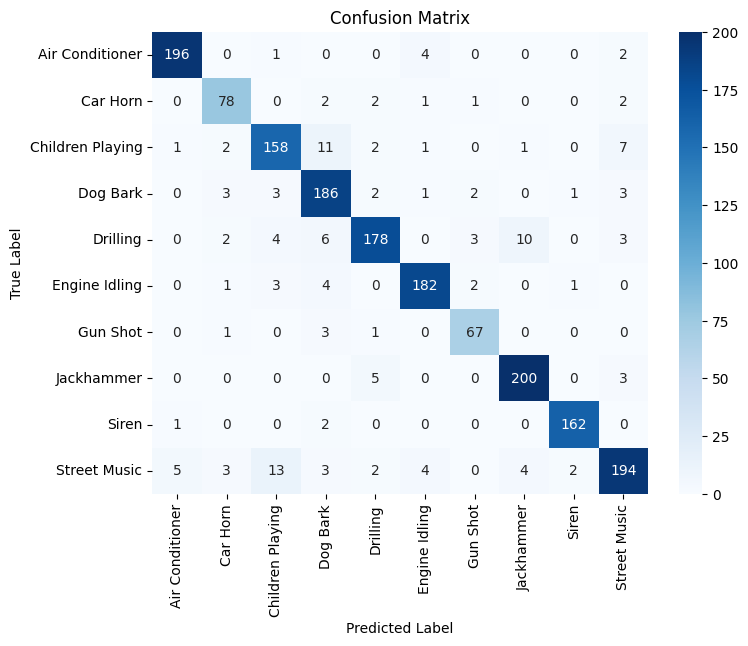

Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.97      0.97       203
           1       0.87      0.91      0.89        86
           2       0.87      0.86      0.87       183
           3       0.86      0.93      0.89       201
           4       0.93      0.86      0.89       206
           5       0.94      0.94      0.94       193
           6       0.89      0.93      0.91        72
           7       0.93      0.96      0.95       208
           8       0.98      0.98      0.98       165
           9       0.91      0.84      0.87       230

    accuracy                           0.92      1747
   macro avg       0.91      0.92      0.92      1747
weighted avg       0.92      0.92      0.92      1747



In [23]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
class_labels = [
    "Air Conditioner",  # 0
    "Car Horn",         # 1
    "Children Playing", # 2
    "Dog Bark",         # 3
    "Drilling",         # 4
    "Engine Idling",    # 5
    "Gun Shot",         # 6
    "Jackhammer",       # 7
    "Siren",            # 8
    "Street Music"      # 9
]

y_pred_probs = model.predict(x_test)  
y_pred = np.argmax(y_pred_probs, axis=1) 

y_true = np.argmax(y_test, axis=1)  # If y_test is one-hot encoded

# Step 3: Compute Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

# Step 4: Plot Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

# Step 5: Print Classification Report
print("Classification Report:\n", classification_report(y_true, y_pred))
